# Яндекс Афиша

### Цели и задачи проекта

Используются данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. 
Цель исследования —  выявить новые предпочтения пользователей осенью 2024 года и проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

### Описание данных

Данные состоят из двух таблиц.
Первый датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Поля датасета:

`order_id` — уникальный идентификатор заказа.

`user_id` — уникальный идентификатор пользователя.

`created_dt_msk` — дата создания заказа (московское время).

`created_ts_msk` — дата и время создания заказа (московское время).

`event_id` — идентификатор мероприятия из таблицы events.

`cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.

`age_limit` — возрастное ограничение мероприятия.

`currency_code` — валюта оплаты, например rub для российских рублей.

`device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.

`revenue` — выручка от заказа.

`service_name` — название билетного оператора.

`tickets_count` — количество купленных билетов.

`total` — общая сумма заказа.

В данные также был добавлен столбец `days_since_prev` с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

Второй датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Обратите внимание, что из данных исключили фильмы, ведь, как было видно на дашборде, событий такого типа не так много. Датасет содержит такие поля:

`event_id` — уникальный идентификатор мероприятия.

`event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.

`event_type_description` — описание типа мероприятия.

`event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.

`organizers` — организаторы мероприятия.

`region_name` — название региона.

`city_name` — название города.

`venue_id` — уникальный идентификатор площадки.

`venue_name` — название площадки.

`venue_address` — адрес площадки.


### Содержимое проекта

Структура проекта:

1. Загрузка данных и знакомство с ними

2. Предобработка данных и подготовка их к исследованию

3. Исследовательский анализ данных

4. Статистический анализ данных

5. Общий вывод и рекомендации

## Загрузка данных и знакомство с ними

In [11]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

Загружаем датасеты

In [12]:
orders = pd.read_csv('/users/aleksandrabritsheva/downloads/final_tickets_orders_df.csv')
events = pd.read_csv('/users/aleksandrabritsheva/downloads/final_tickets_events_df.csv')
tenge = pd.read_csv('/users/aleksandrabritsheva/downloads/final_tickets_tenge_df.csv')

Предварительно проверим данные на совпадение с описанием

In [13]:
orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [14]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [15]:
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [16]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [17]:
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [18]:
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Данные корректны и соответствуют описанию. Далее подробнее их изучим (проверим данные на пропуски, дубликаты (полные, неполные), приведем выручку к единой валюте, проверим категориальные данные, преобразуем типы для оптимального хранения в памяти)

## Предобработка данных и подготовка единого датафрейма

В данном разделе нам предстоит 
- изучить и преобразовать исходные данные
- объединить датафреймы
- провести анализ выручки и количества билетов в заказе
- создать новые столбцы для последующего анализа

### Датасет orders

Перед объединением данных в один датафрейм проверим датасет на пропуски, дубликаты

Рассмотрим orders

In [19]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [20]:
# длина orders исходная
len_ord_orig = len(orders)
len_ord_orig

290849

Проверим на полные дубликаты и пропуски

In [21]:
orders.duplicated().sum()

0

In [22]:
orders.isna().sum()

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

Полных дубликатов нет, пропуски, как заявлено, только в столбце days_since_prev (первичная покупка). Далее изучим неявные дубликаты

Проверим уникальность номера заказа

In [23]:
orders.duplicated(subset=['order_id']).sum()

0

Посмотрим, нет ли разных id пользователя у одного заказа

In [24]:
orders.groupby('order_id')['user_id'].nunique().loc[lambda x: x > 1].count()

0

Заказов, таких, что разным пользователям дали ошибочно один номер заказа, нет.

Далее

Клиент купил билет, но из-за ошибки система создала три разных order_id, (один и тот же человек в одну и ту же секунду покупает одинаковое число билетов на один и тот же ивент)

In [25]:
dupl = orders.duplicated(subset=['user_id', 'event_id', 'created_ts_msk', 'tickets_count'], keep='first').sum()
dupl

44

Обнаружены такие дубликаты. Но так как мы собираемся удалить их, должны пересчитать признак с количеством дней между заказами

In [26]:
orders_clean = orders.drop_duplicates(
    subset=['user_id', 'event_id', 'created_ts_msk', 'tickets_count'], 
    keep='first'
).copy()

In [27]:
orders_clean['created_ts_msk'] = pd.to_datetime(orders_clean['created_ts_msk'])
orders_clean = orders_clean.sort_values(by=['user_id', 'created_ts_msk'])

orders_clean['days_since_prev'] = (
    orders_clean.groupby('user_id')['created_ts_msk']
    .diff()                 
    .dt.total_seconds()    
    / 86400                 
)
orders_clean['days_since_prev'] = orders_clean['days_since_prev'].round(1)

In [28]:
len_ord_new = len(orders_clean)
len_ord_diff = len_ord_orig - len_ord_new
len_ord_perc = round(100 * len_ord_diff / len_ord_orig, 5)
len_ord_new

290805

In [29]:
print(f'После преобразований количество строк датасета orders изменилось на {len_ord_perc}% ')

После преобразований количество строк датасета orders изменилось на 0.01513% 


Датасет orders был проверен на пропуски (только заявленные у первичных покупок), на дубликаты;  были удалены дубликаты (44), связанные созданными повторными заказами (один и тот же человек в одну и ту же секунду покупает одинаковое число билетов на один и тот же ивент). Размер датасета изменился на 0.01513%. Датасет готов к объединению и дальнейшему анализу

### Датасет events

Теперь проверим events на пропуски, дубликаты

In [30]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [31]:
len_ev_orig = len(events)
len_ev_orig

22427

Проверим полные дубликаты, пропуски

In [32]:
events.duplicated().sum()

0

In [33]:
events.isna().sum()

event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

Нет полных дубликатов, пропусков

Проверим уникальность id

In [34]:
events.duplicated(subset=['event_id']).sum()

0

Ищем события с одинаковым содержанием, но разными event_id

In [35]:
content_cols = ['event_name', 'event_type_main', 'organizers', 'city_name', 'venue_id']

In [36]:
event_name_dups = events.duplicated(subset=content_cols, keep=False).sum()
display(f"Количество строк-дубликатов: {event_name_dups}")

if event_name_dups > 0:
    display(events[events.duplicated(subset=content_cols, keep=False)].sort_values('event_name').head(4))

'Количество строк-дубликатов: 1626'

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
22226,587232,0060a0d6-b153-4c35-8057-1ba84cebe2ec,событие,другое,№4421,Речиновская область,Дальнесветск,65,3499,"Творческая инициатива ""Золотая"" Групп","пер. Высоковольтный, д. 98 к. 928"
14727,542092,0060a0d6-b153-4c35-8057-1ba84cebe2ec,событие,другое,№4421,Речиновская область,Дальнесветск,65,3499,"Творческая инициатива ""Золотая"" Групп","пер. Высоковольтный, д. 98 к. 928"
13913,538595,00aebc47-4bb3-4058-b1bf-369ade5d9bfc,событие,другое,№4651,Берёзовская область,Златопольск,74,2997,"Молодежная творческая группа ""Восход"" Инк","пер. Бульварный, д. 3 к. 37"
13949,538642,00aebc47-4bb3-4058-b1bf-369ade5d9bfc,событие,другое,№4651,Берёзовская область,Златопольск,74,2997,"Молодежная творческая группа ""Восход"" Инк","пер. Бульварный, д. 3 к. 37"


Одни и те же события (имя, тип, локация, организатор, город и место проведения совпадают) были ошибочно записаны по несколько раз в таблицу под разными event_id. Оставим только уникальные записи (не забудет и в orders_clean поменять):

In [37]:
id_mapping = events.groupby(content_cols)['event_id'].transform('min')
mapping_dict = dict(zip(events['event_id'], id_mapping))

orders_clean['event_id'] = orders_clean['event_id'].map(mapping_dict).fillna(orders_clean['event_id']).astype(int)

In [38]:
events_clean = events.drop_duplicates(subset=content_cols, keep='first').reset_index(drop=True)

In [39]:
len_ev_new = len(events_clean)
len_ev_diff = len_ev_orig - len_ev_new
len_ev_perc = round(100 * len_ev_diff / len_ev_orig, 3)
len_ev_new, len_ev_diff

(21491, 936)

In [40]:
print(f'После преобразований количество строк датасета events изменилось на {len_ev_perc}% ')

После преобразований количество строк датасета events изменилось на 4.174% 


Датасет orders был проверен на пропуски (нет), на дубликаты;  были удалены дубликаты, связанные с созданными повторными номерами ивента (имя, тип, локация, организатор, город и место проведения совпадают, а номер разный), также номера ивента были изменены в таблице orders_clean. Размер датасета изменился на 4.174%. Датасет готов к объединению и дальнейшему анализу

### Датасет tenge

Теперь проверим корректность датасета для конвертации валют

In [41]:
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [42]:
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [43]:
tenge.duplicated().sum()

0

In [44]:
tenge.isna().sum()

data       0
nominal    0
curs       0
cdx        0
dtype: int64

Нет пропусков и строк-дубликатов

Проверим, что валюта только тенге:

In [45]:
tenge['cdx'].unique()

array(['kzt'], dtype=object)

Проверим, что значение только 100 для конвертации

In [46]:
tenge['nominal'].unique()

array([100])

Проверим, что нет никаких необычных значений:

In [47]:
tenge['curs'].describe()

count    357.000000
mean      19.755818
std        0.833798
min       17.848600
25%       19.120200
50%       19.876000
75%       20.443300
max       21.937100
Name: curs, dtype: float64

Проверим, что нет повторяющихся дат:

In [48]:
tenge.duplicated(subset=['data']).sum()

0

Проверим, что все нужные даты есть:

In [49]:
orders_dates = set(pd.to_datetime(orders['created_dt_msk']).dt.date.unique())
rates_dates = set(pd.to_datetime(tenge['data']).dt.date.unique())
missing_dates = orders_dates - rates_dates
len(missing_dates)

0

### Объединение датасетов

Для дальнейшей работы соединим датасеты orders и events, не теряя заказы с не указанными данными о событии

In [50]:
df = orders_clean.merge(events_clean, on='event_id', how='left')

Изучим получившийся датасет:

In [51]:
orig_len = len(df)
orig_cols = len(df.columns)
orig_len, orig_cols

(290805, 24)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290805 entries, 0 to 290804
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290805 non-null  int64         
 1   user_id                 290805 non-null  object        
 2   created_dt_msk          290805 non-null  object        
 3   created_ts_msk          290805 non-null  datetime64[ns]
 4   event_id                290805 non-null  int64         
 5   cinema_circuit          290805 non-null  object        
 6   age_limit               290805 non-null  int64         
 7   currency_code           290805 non-null  object        
 8   device_type_canonical   290805 non-null  object        
 9   revenue                 290805 non-null  float64       
 10  service_name            290805 non-null  object        
 11  tickets_count           290805 non-null  int64         
 12  total                   290805

In [53]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


In [54]:
df.duplicated().sum()

0

In [55]:
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
event_name                  589
event_type_description      589
event_type_main             589
organizers                  589
region_name                 589
city_name                   589
city_id                     589
venue_id                    589
venue_name                  589
venue_address               589
dtype: int64

Пропуски в days_since_prev мы уже обсуждали.

После выполнения left merge в данных образовались пропуски из-за отсутствия части мероприятий в таблице events.

Пропуски в колонках из бывшего events датасета (589 в каждой строке)

Посмотрим, сколько уникальных event_id не имели описания:

In [56]:
missing_ids = df[df['event_name'].isna()]['event_id'].unique()
display(f"Количество уникальных event_id, которых нет в events: {len(missing_ids)}")

'Количество уникальных event_id, которых нет в events: 26'

Не будем удалять эти строки, чтобы сохранить финансовые метрики (выручку и заказы). Заполним заглушкой, сначала убедившись в ее уникальности. Таким образом также сохраним возможность оптимизации типов данных

In [57]:
text_cols = ['event_name', 'event_type_description', 'event_type_main', 'organizers', 'region_name', 'city_name', 'venue_name', 'venue_address']
num_cols = ['city_id', 'venue_id']

In [58]:
if df[text_cols].isin(["Нет данных"]).any().any():
    print("'Нет данных' уже используется")
else:
    df[text_cols] = df[text_cols].fillna("Нет данных")
    print("Текст заполнен")

if df[num_cols].isin([-1]).any().any():
    print("-1 уже используется")
else:
    df[num_cols] = df[num_cols].fillna(-1).astype(int)
    print("Числа заполнены")

Текст заполнен
Числа заполнены


Пропуски были заполнены уникальными заглушками. Проверим:

In [59]:
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

Теперь нормализуем данные (регистр, пробелы) для объединения скрытых дубликатов

In [60]:
for column in ['cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name', 'event_type_description', 'event_type_main', 'organizers', 'region_name', 'city_name', 'venue_name', 'venue_address']:
    df[column] = df[column].str.lower().str.replace(r'[^\w\s]|_', '', regex=True).str.strip() 

Теперь проверим уникальные значения

In [61]:
df['cinema_circuit'].unique()

array(['нет', 'другое', 'киномакс', 'киносити', 'москино', 'центрфильм'],
      dtype=object)

In [62]:
df['age_limit'].unique()

array([16,  0, 18, 12,  6])

In [63]:
df['currency_code'].unique()

array(['rub', 'kzt'], dtype=object)

In [64]:
df['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [65]:
df['service_name'].unique()

array(['край билетов', 'мой билет', 'за билетом', 'лови билет',
       'билеты без проблем', 'облачко', 'лучшие билеты', 'прачечная',
       'быстробилет', 'дом культуры', 'весь в билетах', 'билеты в руки',
       'тебе билет', 'showticket', 'городской дом культуры', 'яблоко',
       'билет по телефону', 'выступленияру', 'росбилет', 'шоу начинается',
       'мир касс', 'восьмёрка', 'телебилет', 'crazy ticket', 'реестр',
       'быстрый кассир', 'карандашру', 'радио ticket', 'дырокол',
       'вперёд', 'кино билет', 'цвет и билет', 'зе бест', 'тех билет',
       'лимоны', 'билеты в интернете'], dtype=object)

In [66]:
df['event_name'].unique()

array(['f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad',
       '40efeb04-81b7-4135-b41f-708ff00cc64c',
       '01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca', ...,
       'cf71bf2b-8e5c-47e0-a0f3-c2d4910c4677',
       'f17a01b7-3cd3-4cd1-919c-3459bd074886',
       '0fd6df8e-49e5-4337-954d-5a4606b1b899'], dtype=object)

In [67]:
df['event_type_description'].unique()

array(['спектакль', 'событие', 'цирковое шоу', 'выставка', 'шоу',
       'концерт', 'балет', 'спорт', 'мюзикл', 'фестиваль', 'нет данных',
       'ёлка', 'спортивное мероприятие', 'опера', 'музыкальный спектакль',
       'кукольный спектакль', 'оперетта', 'снегурочка', 'рокмюзикл',
       'подарок', 'экскурсия'], dtype=object)

In [68]:
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'нет данных', 'ёлки'], dtype=object)

In [69]:
df['organizers'].unique()

array(['3322', '4850', '1540', ..., '1161', '3497', '1904'], dtype=object)

In [70]:
df['region_name'].unique()

array(['каменевский регион', 'североярская область', 'озернинский край',
       'лугоградская область', 'поленовский край', 'широковская область',
       'медовская область', 'златопольский округ', 'малиновоярский округ',
       'яблоневская область', 'ветренский регион', 'боровлянский край',
       'крутоводская область', 'ягодиновская область',
       'серебряноярский округ', 'нет данных', 'лесодальний край',
       'верхоречная область', 'горицветская область',
       'речиновская область', 'травиницкий округ', 'сосновская область',
       'серебринская область', 'травяная область', 'каменноярский край',
       'солнечноземская область', 'светополянский округ',
       'заречная область', 'ручейковский край', 'глиногорская область',
       'тепляковская область', 'каменноозёрный край',
       'солнечнореченская область', 'зоринский регион',
       'берёзовская область', 'лесостепной край', 'малиновая область',
       'синегорский регион', 'луговая область', 'шанырский регион',
      

In [71]:
df['city_name'].unique()

array(['глиногорск', 'озёрск', 'родниковецк', 'кристалевск',
       'дальнозолотск', 'радужнополье', 'радужсвет', 'кумсай',
       'верховино', 'светополье', 'кокжар', 'каменский', 'лесоярич',
       'никольянов', 'речинцево', 'лесозолотск', 'нет данных',
       'дальнозерск', 'серебрянка', 'островецк', 'родниковец',
       'дальнесветск', 'луговаярово', 'ягодиновка', 'дальнополин',
       'солчелуг', 'озёрчане', 'серебровино', 'лесоярово', 'глинополье',
       'глиноград', 'дальнесветин', 'северополье', 'теплоозеро',
       'горнодолинск', 'ордакент', 'озёрово', 'луговинск', 'лугоград',
       'златопольск', 'крутовинск', 'сарыжар', 'сосновечин', 'тихоярск',
       'яблонецк', 'жаркентай', 'широковка', 'синеводов', 'синеводск',
       'тихосветск', 'радужанов', 'каменосветск', 'глиногорь',
       'родниковск', 'травогород', 'глинянск', 'радужинск', 'поляногорье',
       'дальнолесье', 'ручейник', 'ключеград', 'ключеводск', 'поленовино',
       'речичанск', 'ключевополье', 'шаныртау', 

In [72]:
df['venue_name'].unique()

array(['сценический центр деталь групп',
       'музыкальная школа для детей аккаунт лтд',
       'училище искусств нирвана инк', ...,
       'университет искусств прогресс групп',
       'творческая ярмарка график инк', 'школа музыки парадигма лтд'],
      dtype=object)

In [73]:
df['venue_address'].unique()

array(['алл машиностроителей д 19 стр 6', 'алл шмидта д 9 стр 4',
       'алл юбилейная д 56', ..., 'ш безымянное д 6',
       'алл тепличная д 41', 'пр сплавный д 236 к 918'], dtype=object)

оптимизируем типы численных данных:

In [74]:
for column in ['order_id','event_id','age_limit','tickets_count', 'event_id','city_id','venue_id']:
    df[column] = pd.to_numeric(df[column], downcast='integer')

In [75]:
for column in ['revenue','total','days_since_prev']:
    df[column] = pd.to_numeric(df[column], downcast='float')

и даты к datetime

In [76]:
df["created_dt_msk"] = pd.to_datetime(df["created_dt_msk"])

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290805 entries, 0 to 290804
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290805 non-null  int32         
 1   user_id                 290805 non-null  object        
 2   created_dt_msk          290805 non-null  datetime64[ns]
 3   created_ts_msk          290805 non-null  datetime64[ns]
 4   event_id                290805 non-null  int32         
 5   cinema_circuit          290805 non-null  object        
 6   age_limit               290805 non-null  int8          
 7   currency_code           290805 non-null  object        
 8   device_type_canonical   290805 non-null  object        
 9   revenue                 290805 non-null  float64       
 10  service_name            290805 non-null  object        
 11  tickets_count           290805 non-null  int8          
 12  total                   290805

In [78]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский регион,глиногорск,213,3972,сценический центр деталь групп,алл машиностроителей д 19 стр 6
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,4850,каменевский регион,глиногорск,213,2941,музыкальная школа для детей аккаунт лтд,алл шмидта д 9 стр 4
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,1540,каменевский регион,глиногорск,213,4507,училище искусств нирвана инк,алл юбилейная д 56
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,5049,североярская область,озёрск,2,3574,театр альтернативного искусства ода лимитед,алл есенина д 243 к 38
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,832,озернинский край,родниковецк,240,1896,театр кукол огни инкорпорэйтед,ш набережное д 595 стр 8


Итак, объединили два датасета с заказами и информацией о событиях в один (290805 строк, 24 столбца). Нормализовали и проверили данные на ошибки и скрытые дубликаты, заполнили пропуски уникальными заглушками, оптимизировали типы данных. 

### Анализ выручки и количества билетов

В данном разделе проанализируем выручку и количество билетов в заказе в разрезе по валютам: рублям и тенге

Разобъем анализ по рублям и тенге

In [79]:
df_rub = df[df["currency_code"] == "rub"]
df_kzt = df[df["currency_code"] == "kzt"]

Рассмотрим выручку в рублях

In [80]:
df_rub['revenue'].describe()

count    285737.000000
mean        547.587111
std         871.558344
min         -90.760000
25%         113.870000
50%         346.180000
75%         791.700000
max       81174.540000
Name: revenue, dtype: float64

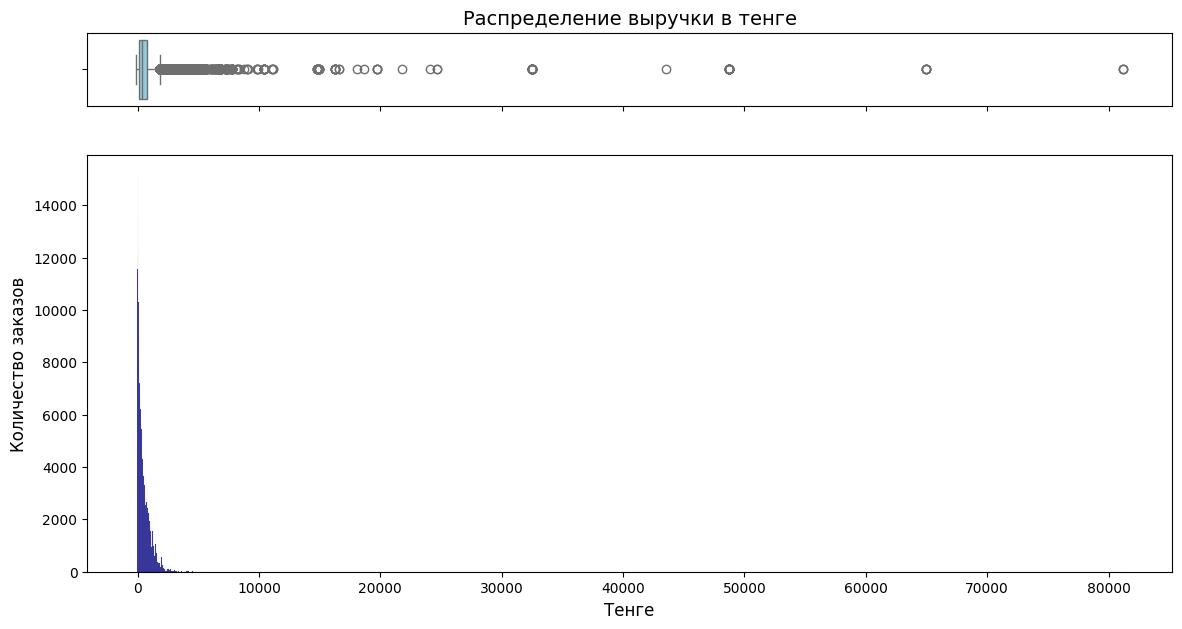

In [81]:
f, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True, gridspec_kw={"height_ratios": (0.15, 0.85)}, figsize=(14, 7)
)

sns.boxplot(x=df_rub["revenue"], orient="h", ax=ax_box, color="skyblue")
sns.histplot(data=df_rub, x="revenue", ax=ax_hist, color="darkblue")

ax_box.set(xlabel="")
ax_box.set_title("Распределение выручки в тенге", fontsize=14)
ax_hist.set_xlabel("Тенге", fontsize=12)
ax_hist.set_ylabel("Количество заказов", fontsize=12)

plt.show()

Среднее больше медианы, много небольших значений (обычно выручка небольшая), но очень крупные значения (групповые заказы, ошибки) завышают среднее. Есть значения выручки меньше нуля (ошибка, так как мы рассматриваем только заказы, а не возвраты), а также выбросы справа; в то время как для 75% заказов чек не превышает 791.70 руб, максимальное значение достигает аномальных 81 174.54 руб. Отберем значения по 99-му процентилю, уберем значения меньше нуля

In [82]:
cleaned_df_rub = df_rub[(df_rub['revenue'] > 0) & (df_rub['revenue'] <= df_rub['revenue'].quantile(0.99))]

In [83]:
cleaned_df_rub['revenue'].describe()

count    276770.000000
mean        521.249896
std         499.759705
min           0.020000
25%         123.390000
50%         355.340000
75%         788.900000
max        2569.590000
Name: revenue, dtype: float64

<Axes: >

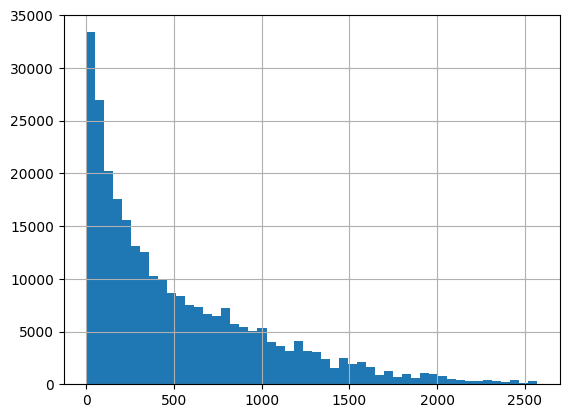

In [84]:
cleaned_df_rub['revenue'].hist(bins=50)

Теперь изучим количество билетов в заказе

In [85]:
cleaned_df_rub['tickets_count'].describe()

count    276770.000000
mean          2.743477
std           1.157516
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          47.000000
Name: tickets_count, dtype: float64

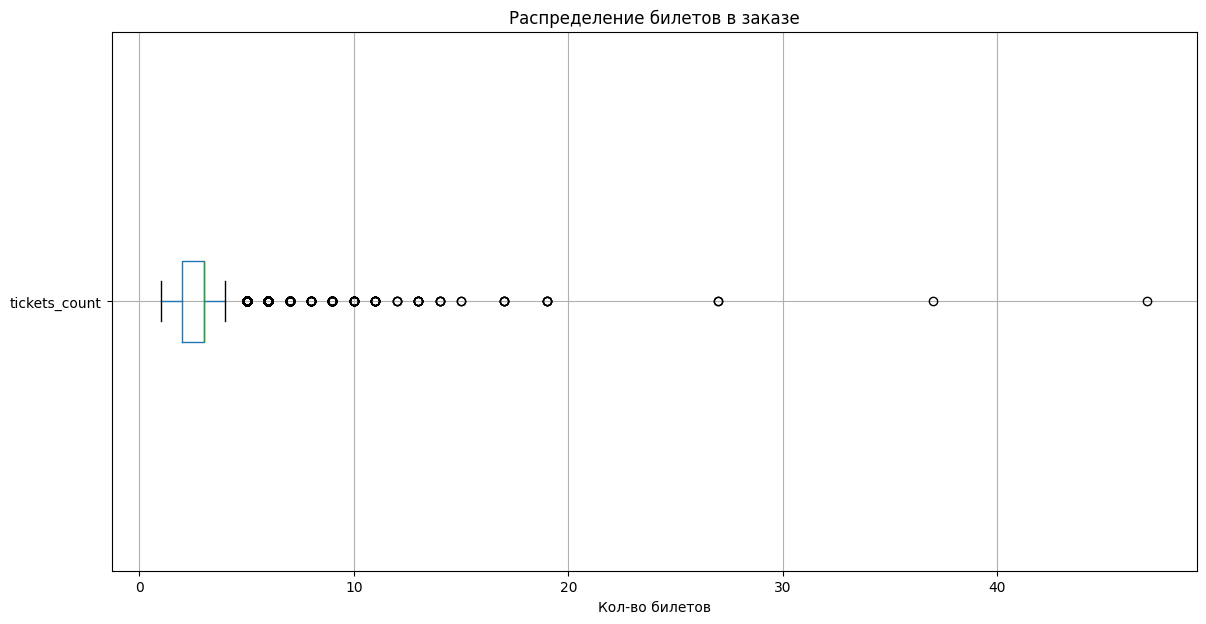

In [86]:
plt.figure(figsize=(14, 7))

cleaned_df_rub.boxplot(column='tickets_count', vert=False)

plt.title('Распределение билетов в заказе')
plt.xlabel('Кол-во билетов')

plt.show()

Описательная статистика распределения кол-ва билетов в заказе демонстрирует стандартное поведение аудитории: среднее число билетов в заказе составляет 2.74, а медианное значение равно 3; минимум - 1 билет, большая часть покупок для развлечения с семьей/друзьями (квартили 25%–75% со значениями 2-3). Максимум в 47 билетов может быть крупной оптовой закупкой, данная аномалия отражает реальные показатели выручки, ее оставляем в датасете.

Теперь рассмотрим заказы в тенге

In [87]:
df_kzt['revenue'].describe()

count     5068.000000
mean      4995.827484
std       4917.039292
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64

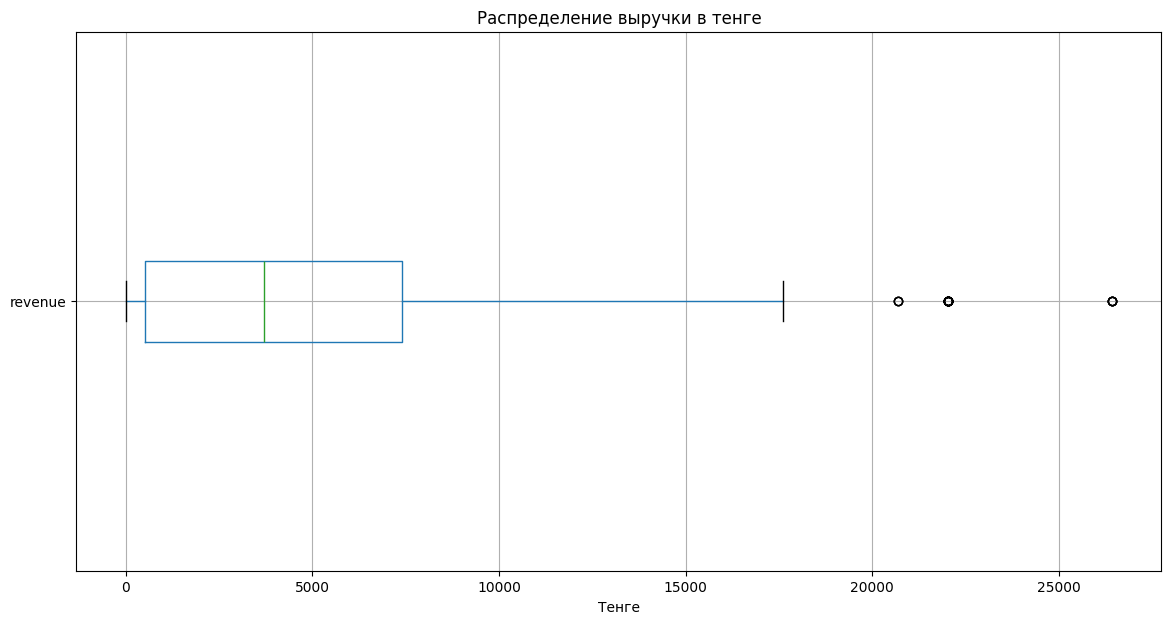

In [88]:
plt.figure(figsize=(14, 7))

df_kzt.boxplot(column='revenue', vert=False)

plt.title('Распределение выручки в тенге')
plt.xlabel('Тенге')

plt.show()

В тенге распределение практически идеальное,  медиана и среднее близки друг к другу, стандартное отклонение не превышает среднее значение - отсутствие перекосов в данных. Выбросы не критичные, находятся недалеко от конца усов боксплота. Минимум = 0 - бесплатная акция билетов.

In [89]:
df_kzt['tickets_count'].describe()

count    5068.000000
mean        2.763220
std         1.115393
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: tickets_count, dtype: float64

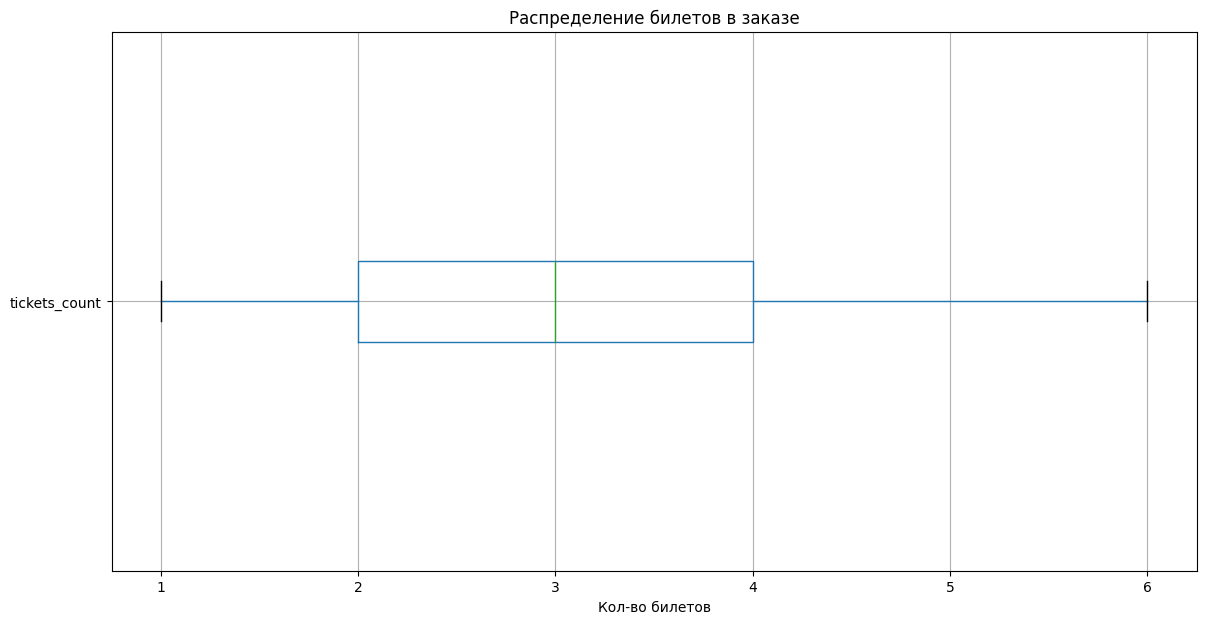

In [90]:
plt.figure(figsize=(14, 7))

df_kzt.boxplot(column='tickets_count', vert=False)

plt.title('Распределение билетов в заказе')
plt.xlabel('Кол-во билетов')

plt.show()

Медианное значение составляет 3 билета, а среднее — 2.76 (совпадает с сегментом в рублях). 75% заказов включают в себя от 2 до 4 билетов. Нет выбросов: в отличие от заказов в рублях (47 билетов максимум), в сегменте тенге максимальный заказ составляет всего 6 билетов - нет закупок или перекупщиков. Сегмент заказов в тенге составлен только розничными покупателями.

In [91]:
df_clean = pd.concat([cleaned_df_rub, df_kzt])
df_clean.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский регион,глиногорск,213,3972,сценический центр деталь групп,алл машиностроителей д 19 стр 6
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,4850,каменевский регион,глиногорск,213,2941,музыкальная школа для детей аккаунт лтд,алл шмидта д 9 стр 4
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,1540,каменевский регион,глиногорск,213,4507,училище искусств нирвана инк,алл юбилейная д 56
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,5049,североярская область,озёрск,2,3574,театр альтернативного искусства ода лимитед,алл есенина д 243 к 38
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,832,озернинский край,родниковецк,240,1896,театр кукол огни инкорпорэйтед,ш набережное д 595 стр 8


В итоге:

Поведение покупателей в разрезе количества билетов на один заказ идентично для обеих валют (медиана — 3 билета), что говорит об однородности аудитории сервиса. Однако сегмент тенге является исключительно розничным, однородным (максимум — 6 билетов, отсутствие транзакций-аномалий), а сегмент рубля имеет признаки крупных групповых бронирований (до 47 билетов в заказе) и технические ошибки учета (отрицательная выручка). В связи с этим фильтрация выбросов по 99-му процентилю была применена только к рублевым транзакциям.

### Создание новых столбцов для предстоящего анализа

Создадим несколько новых столбцов:

- revenue_rub — выручка с заказа в единой валюте — российском рубле. 
- one_ticket_revenue_rub — выручка с продажи одного билета на мероприятие.
- month — месяц оформления заказа.
- season — столбец с информацией о сезонности ('лето', 'осень', 'зима', 'весна').

In [92]:
rates = tenge.set_index("data")["curs"]

df_clean["revenue_rub"] = df_clean["revenue"]

is_kzt = df_clean["currency_code"] == "kzt"
df_clean.loc[is_kzt, "revenue_rub"] = df_clean["revenue"] * (
    df_clean["created_dt_msk"].map(rates) / 100
)

In [93]:
df_clean["one_ticket_revenue_rub"] = df_clean["revenue_rub"] / df_clean["tickets_count"]

In [94]:
df_clean["created_dt_msk"] = pd.to_datetime(df_clean["created_dt_msk"])
df_clean["month"] = df_clean["created_dt_msk"].dt.month

seasons_map = {
    12: "зима",
    1: "зима",
    2: "зима",
    3: "весна",
    4: "весна",
    5: "весна",
    6: "лето",
    7: "лето",
    8: "лето",
    9: "осень",
    10: "осень",
    11: "осень",
}

df_clean["season"] = df_clean["month"].map(seasons_map)

In [95]:
df_clean.tail()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
290678,6862648,ffc24188a1d58f2,2024-07-11,2024-07-11 12:39:48,538828,нет,12,kzt,mobile,4735.52,...,верхоречная область,серебрянка,163,4348,мастерская живого действия юность лтд,наб осенняя д 376,NaN,NaN,7,лето
290679,6763294,ffc24188a1d58f2,2024-09-05,2024-09-05 12:07:00,538828,нет,12,kzt,mobile,4735.52,...,верхоречная область,серебрянка,163,4348,мастерская живого действия юность лтд,наб осенняя д 376,NaN,NaN,9,осень
290680,3984021,ffc24188a1d58f2,2024-09-06,2024-09-06 19:20:03,533803,нет,16,kzt,mobile,1849.41,...,шанырский регион,широковка,162,3407,арткафе речка лимитед,алл путейская д 548 стр 7,NaN,NaN,9,осень
290682,8493898,ffc4133fbba20f4,2024-06-21,2024-06-21 13:41:39,533803,нет,16,kzt,mobile,3698.83,...,шанырский регион,широковка,162,3407,арткафе речка лимитед,алл путейская д 548 стр 7,NaN,NaN,6,лето
290683,8493869,ffc4133fbba20f4,2024-06-21,2024-06-21 14:04:34,533803,нет,16,kzt,mobile,3698.83,...,шанырский регион,широковка,162,3407,арткафе речка лимитед,алл путейская д 548 стр 7,NaN,NaN,6,лето


In [96]:
new_len = len(df_clean)
new_cols = len(df_clean.columns)
display(f'В исходном датасете {orig_len} строк, теперь: {new_len}. Столбцов {new_cols}, было {orig_cols}')

'В исходном датасете 290805 строк, теперь: 281838. Столбцов 28, было 24'

Столбцы были успешно созданы, датасет готов к анализу по сезонам/месяцам

<b>Итоги раздела предобработки</b>

Объединили два датасета. Проверили данные на пропуски, удалили неявные дубликаты. Отфильтровали выручку в рублях и тенге (значения меньше нуля, выбросы). Поправили типы хранения данных, нормализовали. Создали новые столбцы: revenue_rub — выручка с заказа в единой валюте — российском рубле. 
one_ticket_revenue_rub — выручка с продажи одного билета на мероприятие.
month — месяц оформления заказа.
season — столбец с информацией о сезонности: 'лето', 'осень', 'зима', 'весна'.

В исходном датасете 290849 строк, теперь: 230650. Столбцов 28, было 24

## Исследовательский анализ данных

### Спрос по месяцам

Для каждого месяца найдем количество заказов, визуализируем результаты. 

In [97]:
monthly_orders = df_clean.groupby("month")["order_id"].count().reset_index()
monthly_orders.columns = ["month", "orders_count"]
display(monthly_orders)

,month,orders_count
0,6,32932
1,7,37885
2,8,43171
3,9,68861
4,10,98989


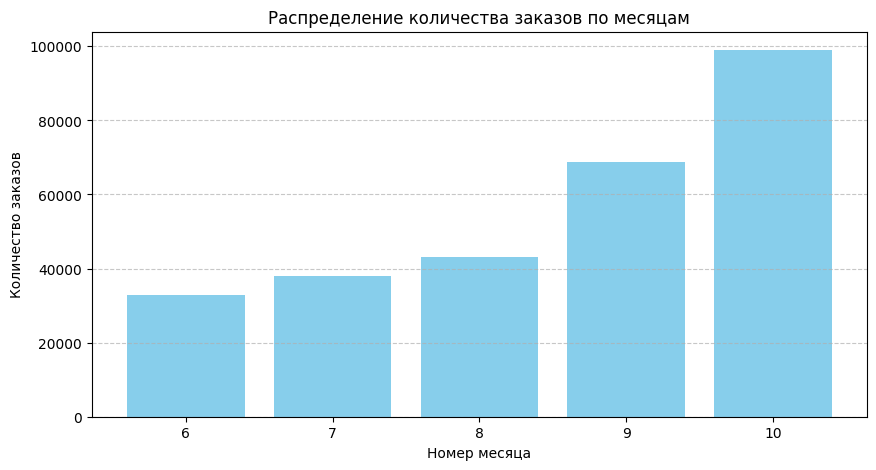

In [98]:
plt.figure(figsize=(10, 5))
plt.bar(
    monthly_orders["month"], monthly_orders["orders_count"], color="skyblue"
)
plt.title("Распределение количества заказов по месяцам")
plt.xlabel("Номер месяца")
plt.ylabel("Количество заказов")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Заметно стремительное увеличение заказов от июня к ноябрю 2024 года. Бизнес растет, есть резкие скачки в Сентябре и Октябре: есть роль сезонности (начало учебного года), возможно, проводимые акции.

### Анализ сезонности

Теперь рассмотрим осенний и летний сезоны и сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу

In [99]:
device_share = (
    df_clean
    .groupby("season")["device_type_canonical"]
    .value_counts(normalize=True)
    .reset_index(name="share")
)

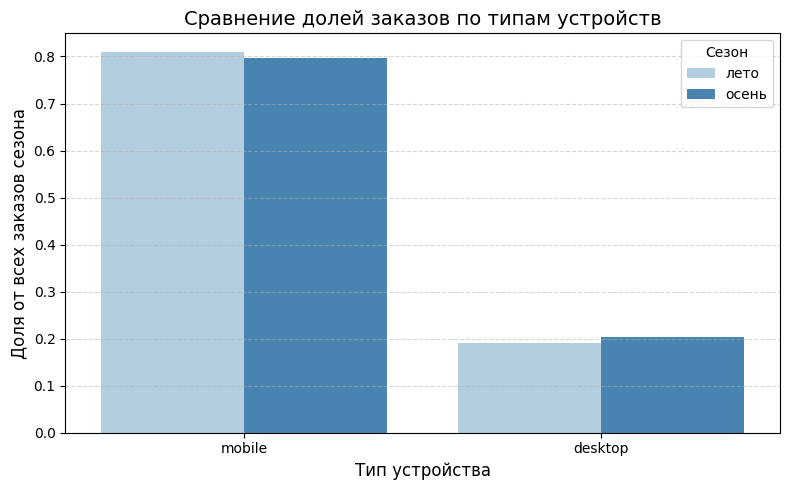

In [100]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=device_share,
    x="device_type_canonical",
    y="share",
    hue="season",
    palette="Blues" 
)

plt.title("Сравнение долей заказов по типам устройств", fontsize=14)
plt.xlabel("Тип устройства", fontsize=12)
plt.ylabel("Доля от всех заказов сезона", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Сезон")
plt.tight_layout()
plt.show()


Заметно пробладание покупок через мобильную версию - около 80% всех заказов платформы как в летний, так и в осенний периоды. Доля покупок через десктопные версии остается на уровне 20%, есть незначительный прирост в осенние месяцы. Такая стабильность пропорций показывает, что рост общего объема заказов осенью происходил равномерно по всем каналам, а закономерность взаимодействия пользователей с платформой не зависит от фактора сезонности

In [101]:
age_share = (
    df_clean
    .groupby("season")["age_limit"]
    .value_counts(normalize=True)
    .reset_index(name="share")
)

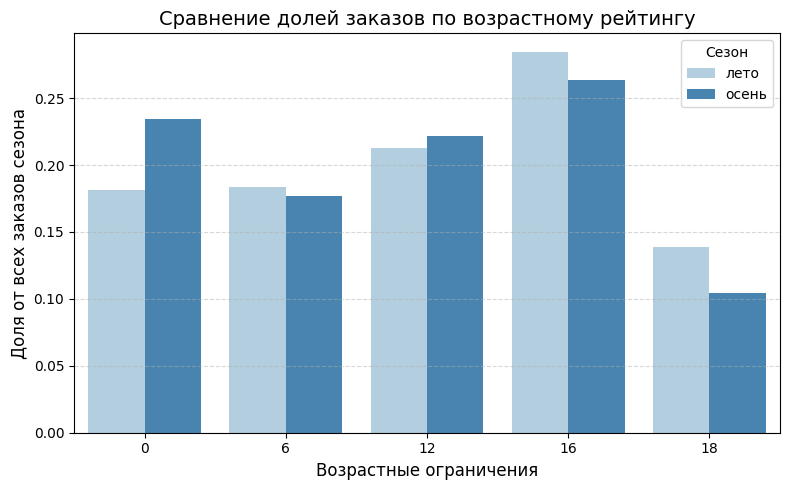

In [102]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=age_share,
    x="age_limit",
    y="share",
    hue="season",
    palette="Blues"
)

plt.title("Сравнение долей заказов по возрастному рейтингу", fontsize=14)
plt.xlabel("Возрастные ограничения", fontsize=12)
plt.ylabel("Доля от всех заказов сезона", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Сезон")
plt.tight_layout()
plt.show()


Категория 16+ является самой популярной как летом, так и осенью. 
С наступлением осени заметен рост кол-ва заказов 0+, 6+, 12+ и упадок 16+ и 18+. Можно аргументировать началом учебного года - дети ходят на мероприятия с классом, студенты заняты учебой.

In [103]:
event_share = (
    df_clean
    .groupby("season")["event_type_main"]
    .value_counts(normalize=True)
    .reset_index(name="share")
)

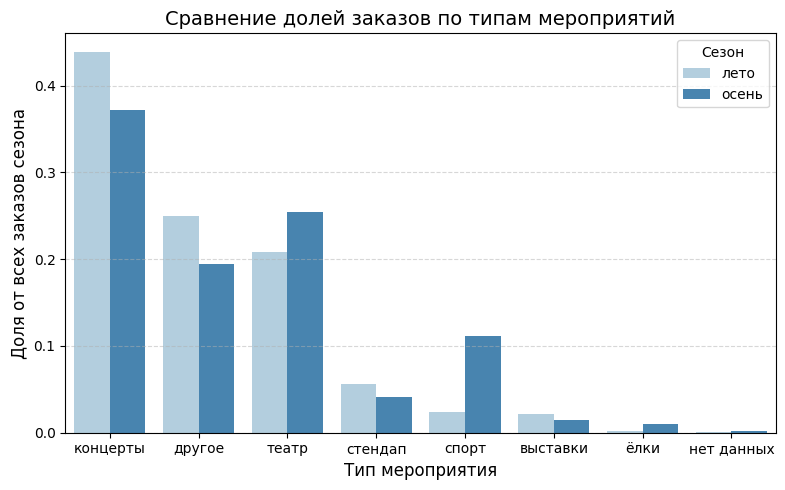

In [104]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=event_share,
    x="event_type_main",
    y="share",
    hue="season",
    palette="Blues",
)

plt.title("Сравнение долей заказов по типам мероприятий", fontsize=14)
plt.xlabel("Тип мероприятия", fontsize=12)
plt.ylabel("Доля от всех заказов сезона", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Сезон")
plt.tight_layout()
plt.show()

В летний период ключевым направлением выступают концерты (около 45% от всех заказов сезона), осенью же направление интереса смещается в сторону театра и спорта. Данные изменения имеют логику: осенью стартуют новые театральные сезоны и регулярные спортивные соревнования. Резкое расширение доли спортивных событий может быть причиной аномальных всплесков активности в начале сентября и октября, массового выкупа билетов на спортивные мероприятия на вместительных стадионах крупными группами.

Итого, видим разность по сезонам в возрастной категории и типе мероприятия, но не в виде устройств. 
Рост бизнеса с июня по октябрь связан с сезонностю и привлечением сегмента - семейных, школьных групп, спортивных секций. Есть смещение с популярных летом концертов (с преимущественно взрослой категорией) на коллективные посещения театров и спортивных состязаний. 


Сейчас в этой интерпретации мы полагаемся лишь на небольшой промежуток одного года, поэтому пока мы можем лишь предполагать наличие сезонности. На динамику могли повлиять и иные факторы, например, специфичные маркетинговые кампании. Чтобы утвержать про наличие сезонности уверенно, нужно убедиться, что паттерн идентичен из года в год.

Теперь посмотрим, как менялась средняя стоимость билета

In [ ]:
agg_report = df_clean.groupby(["event_type_main", "season"]).agg(
    total_revenue=("revenue_rub", "sum"),
    total_tickets=("tickets_count", "sum")
)

agg_report["one_ticket_revenue_rub"] = agg_report["total_revenue"] / agg_report["total_tickets"]

report = agg_report["one_ticket_revenue_rub"].unstack()

report["Изменение %"] = (
    (report["осень"] - report["лето"]) / report["лето"] * 100
).round(1)


In [108]:
report

season,лето,осень,Изменение %
event_type_main,,,
выставки,89.531485,93.462303,4.4
другое,91.463777,82.375122,-9.9
концерты,275.437042,266.757364,-3.2
нет данных,214.133349,263.472609,23.0
спорт,53.604376,49.147801,-8.3
стендап,215.055311,228.698185,6.3
театр,213.398638,176.478793,-17.3
ёлки,263.499330,217.969596,-17.3


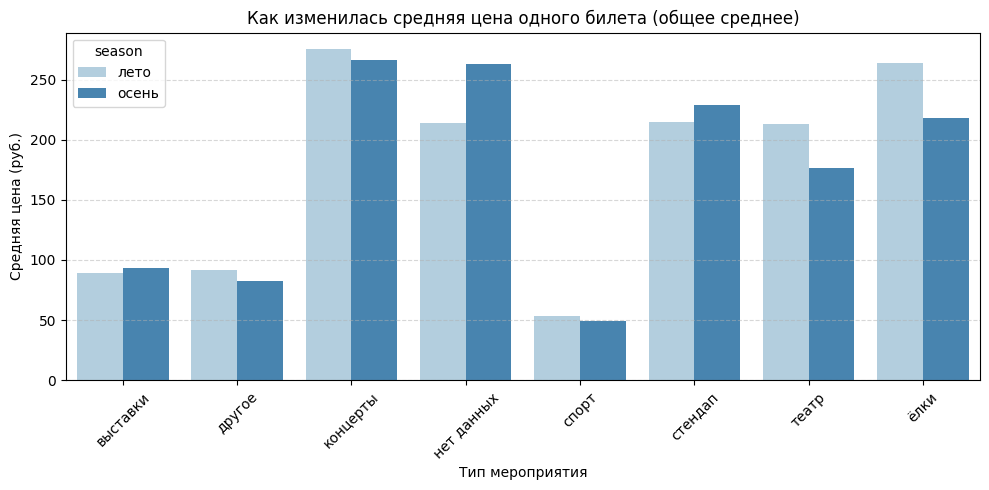

In [ ]:
df_for_plot = df_clean.groupby(["event_type_main", "season"]).agg(
    total_revenue=("revenue_rub", "sum"),
    total_tickets=("tickets_count", "sum")
).reset_index()

df_for_plot["correct_mean_price"] = df_for_plot["total_revenue"] / df_for_plot["total_tickets"]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_for_plot,                
    x="event_type_main",
    y="correct_mean_price",          
    hue="season",
    palette="Blues"

)

plt.title("Как изменилась средняя цена одного билета (общее среднее)")
plt.xlabel("Тип мероприятия")
plt.ylabel("Средняя цена (руб.)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


Средняя стоимость билета в театр снизилась на 17.3%, а на концерты — на 3.2%. Снижение цен на простимулировало спрос. Средняя цена билета на спорт находится на минимальном уровне (49 руб.) - благодаря этому категория показала рост среди осенних заказов. Осенний рост показателей бизнеса был достигнут за счет снижения стоимости билетов, что позволило привлечь массовые группы клиентов.

### Активность по дням (осень)

Изучим активность пользователей осенью 2024 года. Проанализируем динамику по дням

In [132]:
df_autumn = df_clean[df_clean["season"] == "осень"].copy()
df_autumn["created_dt_msk"] = pd.to_datetime(df_autumn["created_dt_msk"])

daily = (
    df_autumn.groupby("created_dt_msk")
    .agg(Заказы=("order_id", "count"),
        Пользователи_DAU=("user_id", "nunique"),
        Средний_чек=("one_ticket_revenue_rub", "mean")).reset_index()
)

daily["Заказов_на_одного"] = daily["Заказы"] / daily["Пользователи_DAU"]

df_autumn["День_недели"] = df_autumn["created_dt_msk"].dt.day_name()
daily


,created_dt_msk,Заказы,Пользователи_DAU,Средний_чек,Заказов_на_одного
0,2024-09-01,1314,555,204.134636,2.367568
1,2024-09-02,1370,571,190.955709,2.399299
2,2024-09-03,5088,776,80.517838,6.556701
3,2024-09-04,1757,683,184.799777,2.572474
4,2024-09-05,1940,738,193.416135,2.628726
...,...,...,...,...,...
56,2024-10-27,2841,1031,187.700949,2.755577
57,2024-10-28,2836,985,172.420377,2.879188
58,2024-10-29,2831,998,179.943294,2.836673
59,2024-10-30,2924,1039,182.775164,2.814244


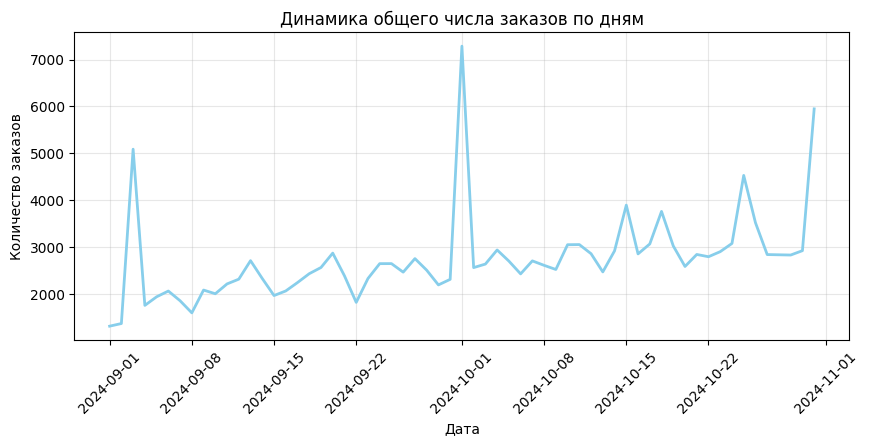

In [133]:
plt.figure(figsize=(10, 4))
plt.plot(daily["created_dt_msk"], daily["Заказы"], color="skyblue", linewidth=2)
plt.title("Динамика общего числа заказов по дням")
plt.xlabel("Дата")
plt.ylabel("Количество заказов")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()


На протяжении всей осени наблюдается рост кол-ва заказов. ВИдна недельная цикличность

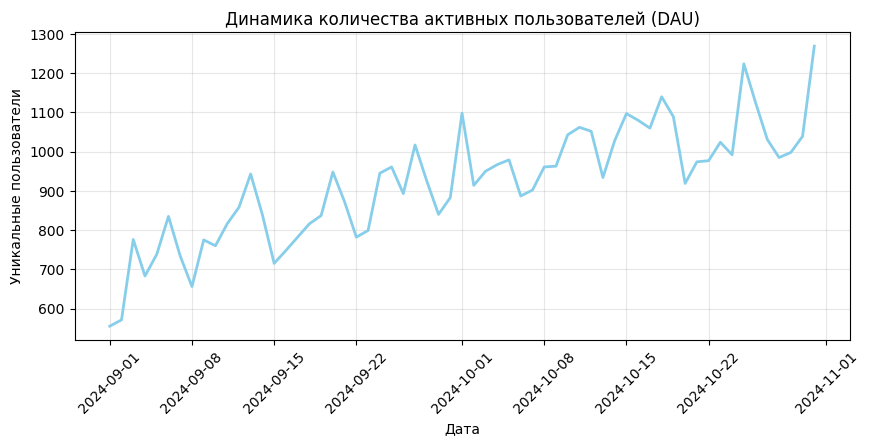

In [134]:
plt.figure(figsize=(10, 4))
plt.plot(
    daily["created_dt_msk"], daily["Пользователи_DAU"], color="skyblue", linewidth=2
)
plt.title("Динамика количества активных пользователей (DAU)")
plt.xlabel("Дата")
plt.ylabel("Уникальные пользователи")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()


Опять же, видим рост количества активных покупателей

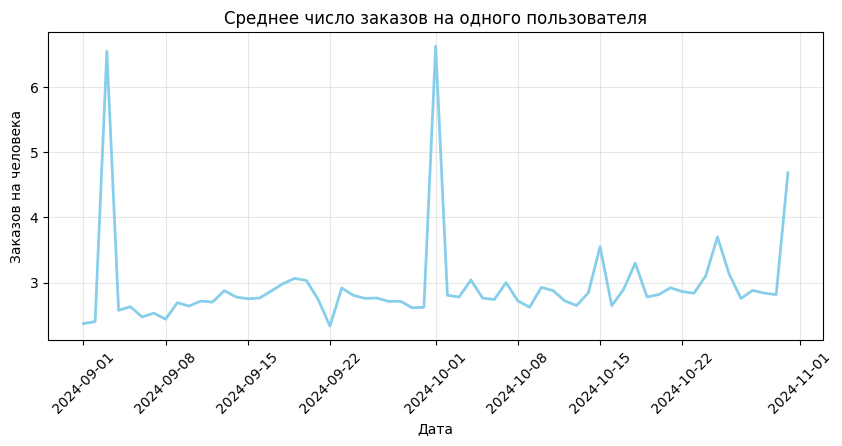

In [135]:
plt.figure(figsize=(10, 4))
plt.plot(
    daily["created_dt_msk"],
    daily["Заказов_на_одного"],
    color="skyblue",
    linewidth=2
)
plt.title("Среднее число заказов на одного пользователя")
plt.xlabel("Дата")
plt.ylabel("Заказов на человека")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()


значение стабильно, медленно возрастает, максимальный всплеск 1 Октября - возможно, много групповых заказов на востребованное событие.

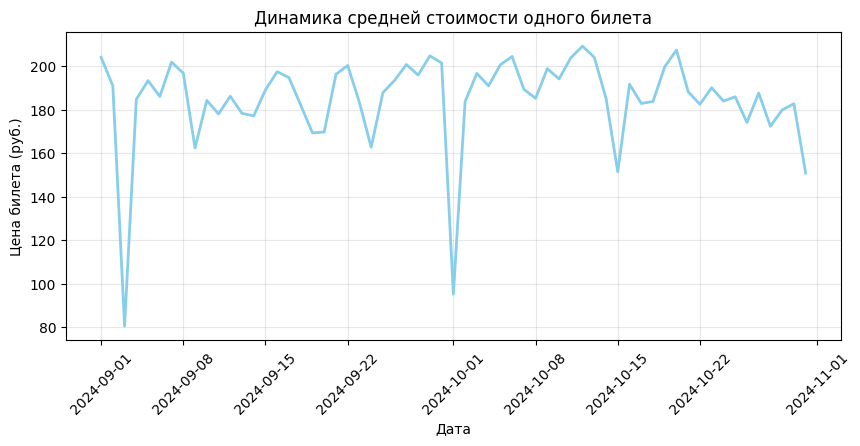

In [136]:
plt.figure(figsize=(10, 4))
plt.plot(
    daily["created_dt_msk"], daily["Средний_чек"], color="skyblue", linewidth=2
)
plt.title("Динамика средней стоимости одного билета")
plt.xlabel("Дата")
plt.ylabel("Цена билета (руб.)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()


На данном графике видим, что 3 сентября и 1 октября была рекордно малая средняя цена на билеты - значит, было очень выгодно покупать билеты (групповые заказы, например на мероприятие для школьников, по оптовым ценам)

Теперь проведем анализ через расчет среднесуточных показателей для каждого дня недели.

In [137]:
daily["День_недели_num"] = daily["created_dt_msk"].dt.dayofweek
daily["День_недели"] = daily["created_dt_msk"].dt.day_name() 

weekday_analysis = (
    daily.groupby(["День_недели_num", "День_недели"])
    .agg(
        Среднее_заказов_в_день=("Заказы", "mean"),
        Среднее_DAU_в_день=("Пользователи_DAU", "mean"),
        Средняя_цена_билета=("Средний_чек", "mean")
    )
    .reset_index()
    .sort_values("День_недели_num")
)

display(weekday_analysis)

,День_недели_num,День_недели,Среднее_заказов_в_день,Среднее_DAU_в_день,Средняя_цена_билета
0,0,Monday,2385.111111,851.666667,185.683303
1,1,Tuesday,3489.000000,932.666667,157.428579
2,2,Wednesday,2535.666667,921.777778,186.703007
3,3,Thursday,3007.666667,960.000000,183.479022
4,4,Friday,3085.500000,1017.000000,187.468831
5,5,Saturday,2648.375000,951.875000,194.412252
6,6,Sunday,2135.777778,813.222222,199.900844


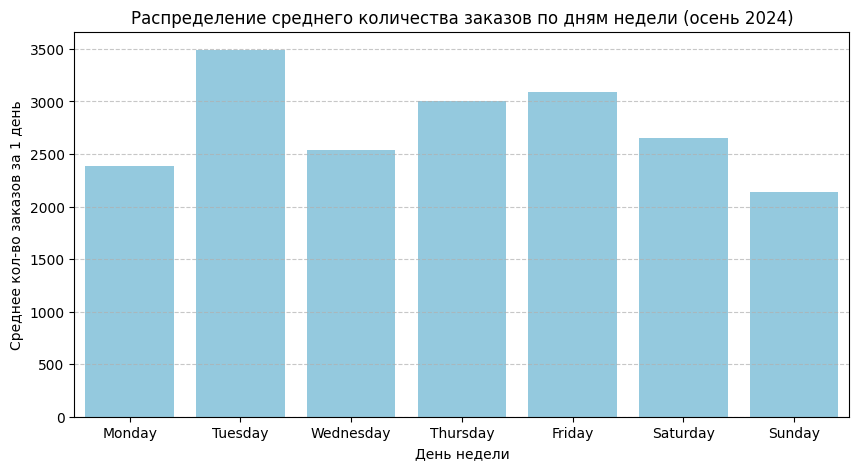

In [138]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=weekday_analysis, 
    x="День_недели", 
    y="Среднее_заказов_в_день",
    color = 'skyblue'
)
plt.title("Распределение среднего количества заказов по дням недели (осень 2024)")
plt.xlabel("День недели")
plt.ylabel("Среднее кол-во заказов за 1 день")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Лидер по активности - пятница: фиксируется максимальное среднесуточное количество заказов (2501.5) и самый высокий показатель DAU (1017 пользователей). Пользователи активно планируют развлечения перед выходными. 

Спад активности: воскресенье и понедельник. В воскресенье 1818.1 заказов, в понедельник - 1982.1. В эти дни пользователи наименее активны, однако в воскресенье фиксируется самая высокая средняя цена билета (199.1 руб): возможно, пользователь покупает себе билет в день мероприятия.

Вторник - аномальный, второй по величине количества заказов (2386.7), но в этот день самая низкая средняя цена билета (169.1 руб.). Эта аномальность происходит из-за того, что 1 октября выпал на вторник

Итог:

В течение осени 2024 года объем ежедневных заказов и количество активных пользователей увеличились более чем в 2 раза. Рост обеспечивается привлечением новой аудитории, т.к. частота покупок на человека остается стабильной.

Посуточный анализ цикличности по дням недели показал, что основной объём спроса приходится на конец рабочей недели (пик в пятницу: ~2500 заказов, DAU > 1000), в то время как в воскресенье и понедельник бизнес происходит прогнозируемый спад активности (до ~1800 заказов).

Наблюдаются две аномалии (3 сентября и 1 октября). В эти дни зафиксировано падение средней стоимости билета до рекордных минимумов при резком скачке частоты покупок на одного человека (до 3.1–3.3). Такое поведение отразилось на метриках вторника. Это причина предполагать об акциях или запуске выгодных оптовых/групповых тарифов, которые привели к таким разовым массовым покупкам.

### Популярность регионов, партнеров

Посмотрим, как события распределены по регионам и партнёрам. Это позволит выделить ключевые регионы и партнёров, которые вносят наибольший вклад в выручку.

In [139]:
total_events_global = df_clean["event_id"].nunique()
total_orders_global = df_clean["order_id"].nunique()

region_analysis = (
    df_clean.groupby("region_name")
    .agg(
        Уникальные_мероприятия=("event_id", "nunique"),
        Всего_заказов=("order_id", "count"),
    )
    .reset_index()
)

region_analysis["Доля_мероприятий"] = (
    region_analysis["Уникальные_мероприятия"] / total_events_global * 100
).round(1)
region_analysis["Доля_заказов"] = (
    region_analysis["Всего_заказов"] / total_orders_global * 100
).round(1)

region_analysis = region_analysis.sort_values(
    by="Уникальные_мероприятия", ascending=False
)
display(region_analysis)


,region_name,Уникальные_мероприятия,Всего_заказов,Доля_мероприятий,Доля_заказов
23,каменевский регион,5535,85275,26.2,30.3
61,североярская область,3662,43534,17.3,15.4
78,широковская область,1156,16072,5.5,5.7
58,светополянский округ,1034,7463,4.9,2.6
53,речиновская область,686,6265,3.2,2.2
...,...,...,...,...,...
69,теплоозёрский округ,2,7,0.0,0.0
67,сосноводолинская область,2,10,0.0,0.0
57,светолесский край,2,24,0.0,0.0
5,верхозёрский край,2,11,0.0,0.0


Есть два уверенных лидера по регионам. Каменевский регион: на него приходится почти треть всех продаж платформы (31.0% заказов) и самое высокое разнообразие событий (5 792 уникальных мероприятия (26.3% от общего числа)). Североярская область: 16.2% заказов, 3 777 уникальных мероприятий (17.2%).

In [140]:
total_revenue_global = df_clean["revenue_rub"].sum()

partner_analysis = (
    df_clean.groupby(["service_name"])
    .agg(
        Уникальные_мероприятия=("event_id", "nunique"),
        Всего_заказов=("order_id", "count"),
        Суммарная_выручка=("revenue_rub", "sum"),
    )
    .reset_index())

partner_analysis["Доля_мероприятий"] = (
    partner_analysis["Уникальные_мероприятия"] / total_events_global * 100
).round(1)
partner_analysis["Доля_заказов"] = (
    partner_analysis["Всего_заказов"] / total_orders_global * 100
).round(1)
partner_analysis["Доля_выручки"] = (
    partner_analysis["Суммарная_выручка"] / total_revenue_global * 100
).round(1)

partner_analysis = partner_analysis.sort_values(
    by="Суммарная_выручка", ascending=False
)
display(partner_analysis)


,service_name,Уникальные_мероприятия,Всего_заказов,Суммарная_выручка,Доля_мероприятий,Доля_заказов,Доля_выручки
3,билеты без проблем,3641,57834,23737153.14,17.2,20.5,16.5
25,облачко,2314,26402,18588613.86,11.0,9.4,12.9
24,мой билет,1223,34465,17789961.89,5.8,12.2,12.3
21,лови билет,4777,40503,16669016.92,22.6,14.4,11.6
8,весь в билетах,849,16409,16493784.46,4.0,5.8,11.4
5,билеты в руки,3417,39820,13196501.04,16.2,14.1,9.1
19,край билетов,249,6109,6405689.22,1.2,2.2,4.4
26,прачечная,1012,10222,4746810.52,4.8,3.6,3.3
13,дом культуры,272,4412,4358655.99,1.3,1.6,3.0
35,яблоко,705,5004,3868336.88,3.3,1.8,2.7


Сервис «Билеты без проблем» занимает первое место по количеству обработанных заказов (21.2%) и приносит наибольшую суммарную выручку: более 20.5 млн рублей (17.0% от общего объема).  При этом он предлагает 4 018 уникальных мероприятий (18.2%). Интересен сервис  "Лови билет": он охватывает больше всех заказов но выручке на 4 месте. Основная доля выручки приходится на несколько компаний - можно выделить топ-6.

## Статистический анализ данных

### Первая гипотеза

Коллеги хотят проверить две гипотезы. Первая:

Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

Нужно убедиться, что группы независимы. Для этого проверим наличие пользователей, которые пользовались и мобильными, и десктопными версиями. Уберем таких пользователей из эксперимента

In [141]:
df_autumn = df_clean[df_clean["season"] == "осень"].copy()

users_device_count = df_autumn.groupby('user_id')['device_type_canonical'].nunique()

dupl_devices = users_device_count[users_device_count > 1]

display(f"Количество пересекающихся пользователей: {len(dupl_devices)}")

'Количество пересекающихся пользователей: 3235'

In [142]:
unique_device_users = users_device_count[users_device_count == 1].index

df_autumn = df_autumn[df_autumn['user_id'].isin(unique_device_users)]

display(f"Удалено пользователей: {len(dupl_devices)}")
display(f"Осталось: {df_autumn['user_id'].nunique()}")

'Удалено пользователей: 3235'

'Осталось: 12499'

Рассмотрим статистику

In [143]:
user_orders = (
    df_autumn.groupby(["user_id", "device_type_canonical"])["order_id"]
    .count()
    .reset_index()
)

stats_df = (
    user_orders.groupby("device_type_canonical")["order_id"]
    .agg(["count", "mean", "median", "std", "var"])
    .round(2)
) 
stats_df

,count,mean,median,std,var
device_type_canonical,,,,,
desktop,1628,1.97,1.0,3.05,9.33
mobile,10871,2.87,2.0,4.15,17.22


10 894 уникальных мобильных пользователей против 1 641 десктопных. У мобильных пользователей среднее - 2.38 заказа, стационарных —  1.60 заказа. У обеих групп медиана равна 1.0. Большая разница в дисперсиях. В группе desktop разброс меньше, то есть поведение пользователей более предсказуемо. 

Только с помощью теста сможем определить, случайность ли различие средних или нет.

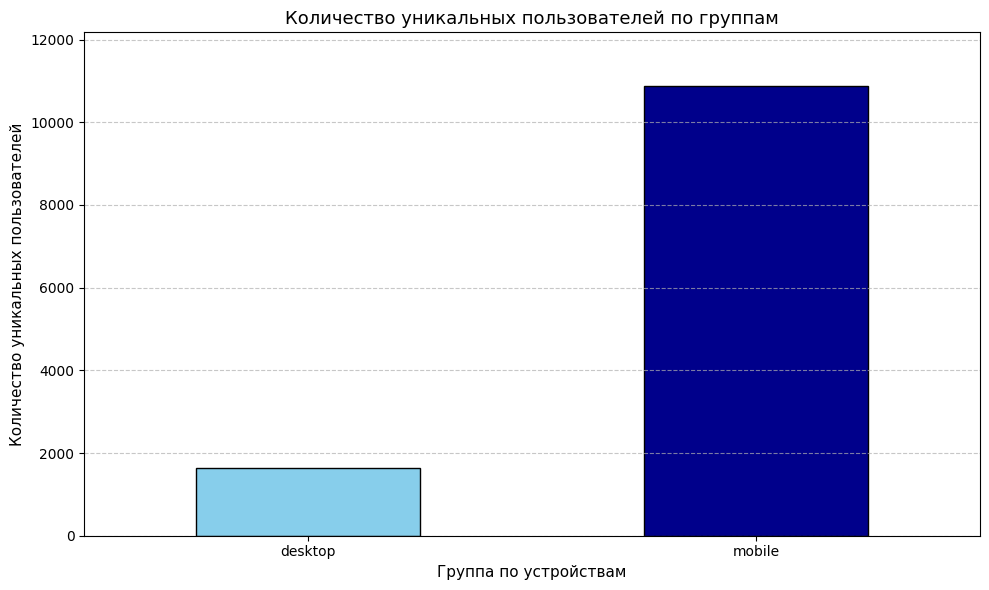

In [144]:
user_orders = df_autumn.groupby("device_type_canonical")["user_id"].nunique()

plt.figure(figsize=(10, 6))  
user_orders.plot(kind="bar", color=["skyblue", "darkblue"], edgecolor="black")

plt.title(
    "Количество уникальных пользователей по группам",
    fontsize=13
)
plt.xlabel("Группа по устройствам", fontsize=11)
plt.ylabel("Количество уникальных пользователей", fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.ylim(0, user_orders.max() * 1.12)

plt.tight_layout()
plt.show()

- Нулевая гипотеза H₀: Среднее количество заказов на одного пользователя в группе mobile меньше или равно среднему количеству заказов в группе desktop.

- Альтернативная гипотеза H₁: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

- Сравниваем средние значения в эксперименте
- Размеры выборок очень различаются
- Дисперсии очень различаются
- На этапе предобработки были полностью исключены пересекающиеся пользователи

Из-за неравенства дисперсий и дисбаланса выборок классический t-тест Стьюдента неприменим. Был выбран t-критерий Уэлча, скорректированный на неравенство дисперсий (equal_var=False). Применение параметрического теста полностью обосновано благодаря Центральной предельной теореме

In [145]:
user_orders = (
    df_autumn.groupby(["user_id", "device_type_canonical"])["order_id"]
    .count()
    .reset_index(name="orders_count")
)
mobile_orders = user_orders[user_orders['device_type_canonical'] == "mobile"][
    "orders_count"
]
desktop_orders = user_orders[
    user_orders["device_type_canonical"] == "desktop"
]["orders_count"]

In [146]:
alpha = 0.05

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    mobile_orders, desktop_orders, equal_var=False, alternative="greater"
)

if p_value_welch_ttest > alpha:
    display(f"pvalue={p_value_welch_ttest:.3e} > {alpha}")
    display("Нулевая гипотеза находит подтверждение")
else:
    display(f"pvalue={p_value_welch_ttest:.3e} < {alpha}")
    display(
        "Нулевая гипотеза НЕ находит подтверждения"
    )


'pvalue=2.472e-25 < 0.05'

'Нулевая гипотеза НЕ находит подтверждения'

На основе проведенного теста получили статистически значимый результат: мобильная активность значимо выше. Это подтверждает, что мобильное приложение является ключевой основой бизнеса. Учитывая, что ранее мы зафиксировали преобладания mobile на уровне 80% от всех заказов, приложение выступает главным двигателем частоты покупок и удержания клиентов.

### Вторая Гипотеза

- Нулевая гипотеза H₀: Среднее время между заказами у пользователей mobile меньше или равно среднему времени у пользователей desktop.

- Альтернативная гипотеза H₁: Среднее время между заказами у пользователей mobile выше, чем у пользователей desktop.

In [147]:
df_sorted = df_autumn.sort_values(by=["user_id", "created_ts_msk"])
df_sorted["created_ts_msk"] = pd.to_datetime(df_sorted["created_ts_msk"])

time_diff = (
    df_sorted.groupby("user_id")["created_ts_msk"]
    .diff()
    .dt.total_seconds()
    / (3600 * 24)
)

stats_df = (
    df_sorted.assign(time_diff=time_diff)  
    .dropna(subset=["time_diff"])
    .groupby(["user_id", "device_type_canonical"])["time_diff"]
    .mean()
    .reset_index()
    .groupby("device_type_canonical")["time_diff"]
    .agg(["count", "mean", "median", "std", "var"])
    .round(2)
)

stats_df

,count,mean,median,std,var
device_type_canonical,,,,,
desktop,583,3.95,0.01,8.91,79.41
mobile,5544,6.64,3.04,9.32,86.87


Метрики распределения времени между заказами демонстрируют сильную правостороннюю асимметрию и неравность между дисперсиями (дисперсия mobile составляет 86.87, а desktop — 79.41) а также дисбаланс объема выборок. Учиьывая ЦПТ рименение критерия Уэлча обосновано.

С точки зрения бизнес-логики, полученные метрики выявили парадокс: несмотря на то, что ранее мобильные пользователи показали более высокую общую частоту покупок за сезон, среднее время между их заказами оказалось выше (6.64 дня против 3.95 у десктопа). Низкий показатель десктопа (медиана 0.01 дня) обусловлен закономерностью покупок, когда несколько билетов оформляются последовательно в течение нескольких минут, в то время как мобильные пользователи совершают более распределенные во времени заказы.

In [148]:
user_time = (
    df_sorted.assign(time_diff=time_diff)
    .dropna(subset=["time_diff"])
    .groupby(["user_id", "device_type_canonical"])["time_diff"]
    .mean()
    .reset_index()
)

mobile_time = user_time[user_time["device_type_canonical"] == "mobile"][
    "time_diff"
]
desktop_time = user_time[user_time["device_type_canonical"] == "desktop"][
    "time_diff"
]

Запускаем тест Уэлча

In [149]:
alpha = 0.05
stat_welch, p_value_welch = stats.ttest_ind(
    mobile_time, desktop_time, equal_var=False, alternative="greater"
)

if p_value_welch > alpha:
    print(f"p-value = {p_value_welch:.3e} > {alpha}")
    print("Нулевая гипотеза подтверждается")
else:
    print(f"p-value = {p_value_welch:.3e} < {alpha}")
    print(
        "Нулевая гипотеза ОТВЕРГНУТА"
    )

p-value = 5.128e-12 < 0.05
Нулевая гипотеза ОТВЕРГНУТА


А/Б-тест подтвердил гипотезу: интервалы между заказами у мобильных пользователей значимо длиннее, чем у десктопных. Это доказывает разницу в характере покупок: десктоп используется для покупок нескольких билетов подряд (из-за чего интервалы минимальны), в то время как мобильное приложение сфокусировано на регулярном, распределённом во времени спросе

### Промежуточный итог по проверке гипотез

Сопоставление результатов двух экспериментов раскрывает фундаментальную разницу в характере поведения аудитории на разных платформах:

-  Desktop: Пользователи десктопной версии совершают меньше заказов за сезон, но делают оформляют несколько билетов один за другим с минимальным интервалом. Сайт используется как инструмент для разовой, точечной закупки на компанию или мероприятие.
-  Mobile: Мобильные пользователи совершают гораздо больше заказов за сезон, но эти заказы равномерно распределены во времени.

## Общий вывод и рекомендации

<b>Сезонность. Рост </b>

Бизнес демонстрирует рост: к октябрю объем ежемесячных заказов взлетел почти в 3 раза по сравнению с июнем, достигнув пика в 100 тыс. за месяц. Этот успех обеспечен притоком новой активной аудитории на фоне сезонных изменениях в спросе. Летом доминировали индивидуальные покупки на взрослые концерты, а осенью фокус сместился на коллективный семейный досуг: зафиксирован взлет доли спорта и рост популярности театров.

Взрывной спрос в сентябре и октябре был простимулирован снижением цен на театры и концерты, а также дешевыми билетами на спорт. Это позволило привлечь массовые организованные группы; и хотя частота покупок в дни акций взлетала до аномальных 3.3 билета на человека, это происходило за счет падения среднего чека на 30–40%.

Рекомендации: В конце августа - начале сентября запускать рекламу, ориентированную на организаторов групп (родительские комитеты, школы, спортивные школы) в регионах-лидерах (Каменевский регион и Североярская область). Можно внедрить групповые билеты, сделать скидку при покупке на группу. Добьемся масштабирования покупок в пиковый сезон. Так как desktop сайт используется для планирования совместных поездок, нужно оптимизировать его под эту цель. Это увеличит покупки и на сайте.

<b>Разделение платформ </b>

- Платформа Mobile составляет 80% заказов. Они возвращаются в приложение регулярно с паузой в примерно 3 дня.
- Платформа Desktop составляет всего 20% заказов. Пользователь покупает редко, но оформляет несколько билетов один за другим (интервал между оформлениями стремится к нулю).

Рекомендации: Сфокусироваться на мобильных устройствах (разница в пользовании слишком велика, чтобы растрачиваться на продвижение desktop). Поддерживать регулярное пользование на мобильных устройствах: 2-3 раза в неделю присылать пуш-уведомление с рекомендацией на основе персональных предпочтений. Так регулярные покупки сохранятся, повысится удержание покупателя.

<b>Популярность</b>

Концентрация преобладающей доли выручки всего на шести компаниях-продавцах билетов создает риски для стабильности сервиса. Необходимо расширить эту группу за счет интеграции с новыми билетными операторами. Также есть необходимость разных подходов к топ-агрегаторам: есть высокозарабатывающие на меньшем числе заказов, как «Весь в билетах», есть "Лови билет", который охватывает много заказов но зарабатывает меньше. Повысим стабильность, снизим риск, максимизируем прибыль.

Также в приоритете развитие второстепенных регионов (Широковская область, Светополянский округ) посредством расширения туда высокообещающих операторов («Край билетов», «Прачечная»), поддержка местных развивающихся онлайн-касс в отстающих регионах. Сбалансируем сеть, найдем нновые точки роста.